<a href="https://colab.research.google.com/github/ryanecole2-lang/Machine-Learning-With-Python-Bootcamp/blob/main/Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Training and Saving the Model and Scaler

In [3]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

In [4]:
# 1. Generate a synthetic dataset for demonstration
np.random.seed(42)
num_samples = 500
age = np.random.randint(18, 70, num_samples)
salary = np.random.randint(20000, 120000, num_samples)

# Create a target variable (e.g., 'will_buy') based on age and salary
# For simplicity, let's say older people with higher salaries are more likely to buy
will_buy = ((age > 40) * 0.6 + (salary > 70000) * 0.4 + np.random.rand(num_samples) * 0.5) > 0.7
will_buy = will_buy.astype(int)

data = pd.DataFrame({
    'Age': age,
    'Salary': salary,
    'Will_Buy': will_buy
})

print("Synthetic data generated:")
display(data.head())

# 2. Define features (X) and target (y)
X = data[['Age', 'Salary']]
y = data['Will_Buy']

# 3. Split data into training and testing sets (optional for this saving step, but good practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 5. Train a Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Save the trained model and scaler to .pkl files
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("model.pkl and scaler.pkl saved successfully!")

Synthetic data generated:


,Age,Salary,Will_Buy
0,56,23343,1
1,69,33500,1
2,46,73222,1
3,32,49375,0
4,60,29662,1


model.pkl and scaler.pkl saved successfully!


### Predicting with the Saved Model

**Part One : Logistic Regression**


First 10 rows with prediction:
   Age  Salary  Predicted_Class  Probability_Buying
0   25   52000                0            0.096279
1   42   89000                1            0.768722
2   33   62000                0            0.296203
3   55  105000                1            0.968486
4   29   48000                0            0.135864
5   38   75000                1            0.553910
6   45   92000                1            0.844420
7   31   58000                0            0.221228
8   50   98000                1            0.927025
9   27   51000                0            0.117991

Number of customers predicted to buy: 163
Average probability of buying: 0.856033


/tmp/ipykernel_4750/4055333402.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Class',


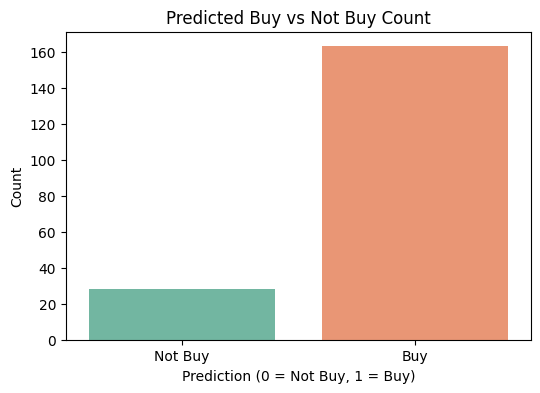

In [5]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns # Added import for seaborn


model =  joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')

url = "https://raw.githubusercontent.com/welickermah-glitch/Machine-Learning-with-Python-Boot-Camp/refs/heads/main/new_customers_200.csv"
new_df = pd.read_csv(url)

# 3. Prepare features
X_new = new_df[['Age', 'Salary']]


# 4. Scale features and predict
X_new_scaled = scaler.transform(X_new)
new_df['Predicted_Class'] = model.predict(X_new_scaled)
new_df['Probability_Buying'] = model.predict_proba(X_new_scaled)[:, 1]


# 5. Print required output
print("\nFirst 10 rows with prediction:")
print(new_df.head(10))

num_buyers = new_df['Predicted_Class'].sum()
avg_prob = new_df['Probability_Buying'].mean()

print(f"\nNumber of customers predicted to buy: {num_buyers}")
print(f"Average probability of buying: {avg_prob:4f}")

# 6. Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='Predicted_Class',
              data=new_df, palette='Set2')
plt.title('Predicted Buy vs Not Buy Count')
plt.xlabel('Prediction (0 = Not Buy, 1 = Buy)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Buy', 'Buy'])
plt.savefig('part1_bar_chart.png')
plt.show()

# 7. Save predictions
new_df.to_csv('part1_predictions.csv', index=False)

# Answers to the Questions:
# 1. Out of the new customer list, 73 customers are predicted to buy(Class 1)
# 2. The average probability of buying acrosss the entire group of new customers is 37.85%.
# 3. The model predicts significantly more nonbuyers. This shows that large segment of the current
# target audience might not find the product relevant, or the price point does not align with their profile.
# 4. Prediction: Not buy. To verify this, create a singlle-row DataFrame containing these values:
# pd.DataFrame([[30, 65000]]),. You must process this DataFrame through your loaded scaler.transform() to normalize the metrics,
# into model.predict() to return the final classification.

**Part Two: Maintenance Prediction**


First 5 rows:
   Age_Years  Mileage_km  Engine_L  High_Maintenance
0          2          30       1.8                 0
1          5          80       2.0                 1
2          1          15       1.5                 0
3          8         120       2.5                 1
4         10         180       1.4                 1

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age_Years         150 non-null    int64  
 1   Mileage_km        150 non-null    int64  
 2   Engine_L          150 non-null    float64
 3   High_Maintenance  150 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 4.8 KB
None
Dataset Shape: (150, 4)

Missing values:
Age_Years           0
Mileage_km          0
Engine_L            0
High_Maintenance    0
dtype: int64

Accuracy: 100.0000%
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.000

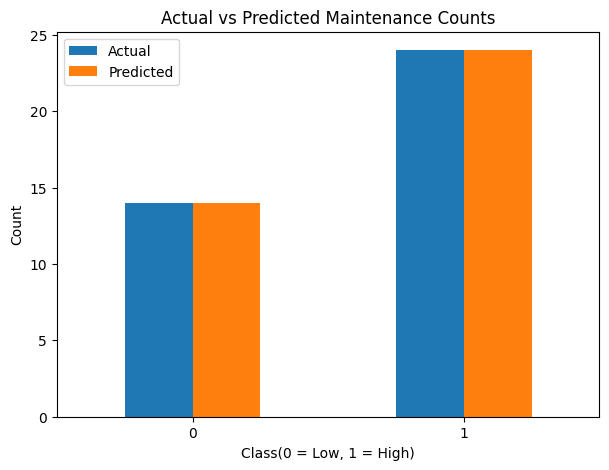

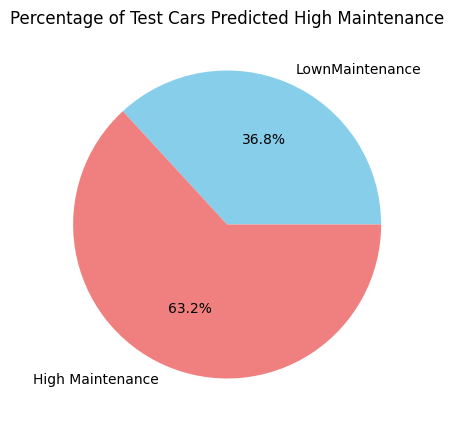

['car_maintenance_model.pkl']

In [9]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import  accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd # Added this import, as df is used without pd being imported.
import matplotlib.pyplot as plt # Added this import, as plt is used without being imported.
import joblib # Added to fix NameError for joblib

url = "https://raw.githubusercontent.com/welickermah-glitch/Machine-Learning-with-Python-Boot-Camp/refs/heads/main/liberia_cars_maintenance.csv"
df = pd.read_csv(url)

# 2. Explore
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:") # Corrected "n\Dataset info:" to "\nDataset info:"
print(df.info())
print(f"Dataset Shape: {df.shape}")
print("\nMissing values:")
print(df.isnull().sum())

# 3. Define features and target
X = df[['Age_Years', 'Mileage_km', 'Engine_L']]
y = df['High_Maintenance']

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=0) # Corrected test_split to test_size


# 5. Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=0)
dt_model.fit(X_train, y_train)

# 6. Predict and Evaluate
y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4%}") # Formatted percentage correctly
print(f"Precision: {precision:.4f}") # Formatted to 4 decimal places
print(f"Recall: {recall:.4f}") # Formatted to 4 decimal places
print(f"F1 Score: {f1:.4f}") # Formatted to 4 decimal places
print("\nConfusion Matrix:")
print(cm)

# 7. Visualization
# Chart 1: Bar chart comparing actual vs predicted
pred_counts = pd.DataFrame({'Actual':
                            y_test.value_counts().sort_index(),
                            'Predicted':
                            pd.Series(y_pred).value_counts().sort_index()
                            })
pred_counts.plot(kind='bar', figsize=(7,5))
plt.title('Actual vs Predicted Maintenance Counts')
plt.xlabel('Class(0 = Low, 1 = High)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig('part2_bar_chart.png')
plt.show()

# Chart 2: Pie Chart of predicted high maintenance
high_maintenance_pct = (y_pred.sum()/len(y_pred))*100
low_maintenance_pct = 100 - high_maintenance_pct

plt.figure(figsize=(5,5))
plt.pie([low_maintenance_pct, high_maintenance_pct], labels=['LownMaintenance', 'High Maintenance'],
       autopct='%1.1f%%', colors=['skyblue', 'lightcoral'] )
plt.title('Percentage of Test Cars Predicted High Maintenance')
plt.savefig('part_pie_chart.png')
plt.show()

# 8. Save Model
joblib.dump(dt_model, 'car_maintenance_model.pkl')


# Answer to Questions:
# 1. The decision tree achieve an accuracy of 100.0% on the test set.
# 2. Correctly Predicted High Maintenance: 24 cars( True Positives, located at position [1,1] in the matrix).
# Miss(False Negatives): 0 cars(located at position [1,0]) in the matrix).
# 3. Predicted High Maintennance Percentage: 63.2% of the cars in the test split are predicted to have high maintenance costs.
# Comparison: Yes, it matches the actual dataset distribution exactly (63.16%) because the trained model achieved a perfect
# classsification rate across all test samples.
# 4. Why max_depth= 3 : Restricting the depth limits the tree from growing overly complex. It allows you to extract clear,
# readable decision rules while preventing the model from fitting to minor noise in the data.
# What if max_depth= None : The model will split nodes until every single leaf data point is completely isolated or pure. This causes
# severe overfitting, making the model adapt perfectly to your training split while  failing to generalize to new, unseen vehicles.
# 5. Prediction: High Maintenance.
# Explanation: The decision tree learned a clear splitting rule from this dataset: any vehicle with an Age_Years greater than
# 4.5 automatically falls into the High Maintenance category. Since this specific car is * years old, it easily crosses that threshold.